# Initial EDA: Crypto Meme Coin Dashboard

This notebook extends the initial exploration with volatility analysis, coin comparison, and Power BI-ready insights. The goal is to support dashboard storytelling for meme coins and benchmark coins together.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
import yfinance as yf
from pathlib import Path

plt.style.use('seaborn-v0_8')
DATA_PATH = Path('../data/interim/master_cleaned.csv')
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df.head()

,date,coin_id,price,volume,market_cap,daily_return_pct,price_7d_ma,volume_7d_ma
0,2025-04-28,bitcoin,93809.337820,1.592626e+10,1.862772e+12,NaN,NaN,NaN
1,2025-04-29,bitcoin,95030.606455,3.191381e+10,1.887067e+12,1.301863,NaN,NaN
2,2025-04-30,bitcoin,94256.359463,2.588263e+10,1.870818e+12,-0.814734,NaN,NaN
3,2025-05-01,bitcoin,94235.753310,2.654170e+10,1.871350e+12,-0.021862,NaN,NaN
4,2025-05-02,bitcoin,96426.945223,3.020757e+10,1.914884e+12,2.325224,NaN,NaN


In [3]:
df.shape

(1464, 8)

In [4]:
df["coin_id"].value_counts()

coin_id
bitcoin           366
dogwifcoin        366
floki             366
official-trump    366
Name: count, dtype: int64

In [5]:
df["date"].min(), df["date"].max()

(Timestamp('2025-04-28 00:00:00'), Timestamp('2026-04-27 00:00:00'))

In [6]:
print('Rows:', len(df))
print('Columns:', df.shape[1])
print('Coins:', df['coin_id'].nunique())
print('Date range:', df['date'].min(), '->', df['date'].max())
print('Missing values by column:')
print(df.isnull().sum())


Rows: 1464
Columns: 8
Coins: 4
Date range: 2025-04-28 00:00:00 -> 2026-04-27 00:00:00
Missing values by column:
date                 0
coin_id              0
price                0
volume               0
market_cap           0
daily_return_pct     4
price_7d_ma         24
volume_7d_ma        24
dtype: int64


## Volatility

Meme coins show higher volatility, meaning larger price swings and higher risk.  
Bitcoin is more stable with lower daily fluctuations.

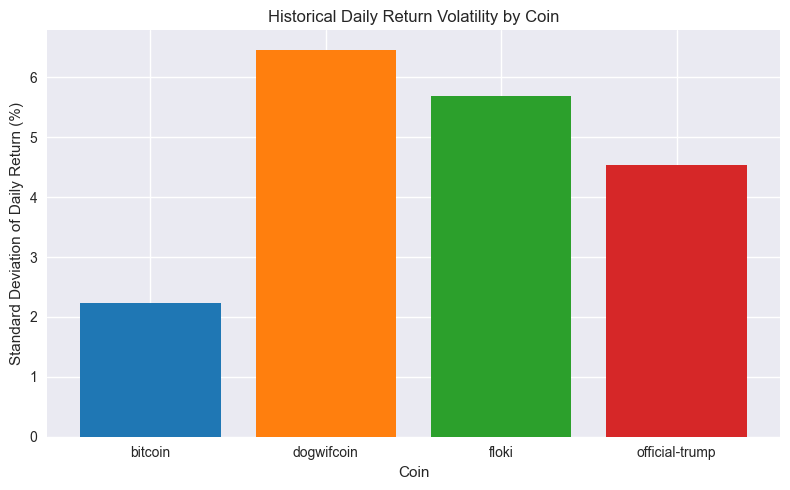

,coin_id,return_volatility
0,bitcoin,2.23
1,dogwifcoin,6.46
2,floki,5.68
3,official-trump,4.53


In [7]:
volatility = df.groupby('coin_id')['daily_return_pct'].std().reset_index()
volatility.columns = ['coin_id', 'return_volatility']
volatility['return_volatility'] = volatility['return_volatility'].round(2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(volatility['coin_id'], volatility['return_volatility'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_title('Historical Daily Return Volatility by Coin')
ax.set_xlabel('Coin')
ax.set_ylabel('Standard Deviation of Daily Return (%)')
plt.tight_layout()
plt.show()
volatility

## Summary Metrics
Provides an overview of price, volume, returns, and volatility per coin.  
Helps compare overall performance and market behavior.

In [8]:
summary = df.groupby('coin_id').agg(
    avg_price=('price', 'mean'),
    avg_volume=('volume', 'mean'),
    avg_market_cap=('market_cap', 'mean'),
    avg_daily_return=('daily_return_pct', 'mean'),
    volatility_30d=('daily_return_pct', lambda x: x.rolling(30).std().mean()),
).reset_index()
summary['avg_price'] = summary['avg_price'].round(2)
summary['avg_volume'] = summary['avg_volume'].round(0)
summary['avg_market_cap'] = summary['avg_market_cap'].round(0)
summary['avg_daily_return'] = summary['avg_daily_return'].round(2)
summary['volatility_30d'] = summary['volatility_30d'].round(2)
summary

,coin_id,avg_price,avg_volume,avg_market_cap,avg_daily_return,volatility_30d
0,bitcoin,96568.82,4.651588e+10,1.925015e+12,-0.03,2.13
1,dogwifcoin,0.58,2.490374e+08,5.747580e+08,-0.13,6.26
2,floki,0.00,9.951483e+07,6.480283e+08,-0.08,5.48
3,official-trump,7.07,4.230301e+08,1.438883e+09,-0.38,4.14


### SQL Aggregation
SQL is used to summarize key metrics per coin.  
Demonstrates ability to query data efficiently using SQL.

In [9]:
query = '''
SELECT
    coin_id,
    COUNT(*) AS observations,
    MIN(date) AS first_date,
    MAX(date) AS last_date,
    AVG(price) AS avg_price,
    AVG(volume) AS avg_volume,
    AVG(market_cap) AS avg_market_cap
FROM df
GROUP BY coin_id
ORDER BY avg_market_cap DESC
'''
coin_compare = duckdb.query(query).to_df()
coin_compare['avg_price'] = coin_compare['avg_price'].round(2)
coin_compare['avg_volume'] = coin_compare['avg_volume'].round(0)
coin_compare['avg_market_cap'] = coin_compare['avg_market_cap'].round(0)
coin_compare

,coin_id,observations,first_date,last_date,avg_price,avg_volume,avg_market_cap
0,bitcoin,366,2025-04-28,2026-04-27,96568.82,4.651588e+10,1.925015e+12
1,official-trump,366,2025-04-28,2026-04-27,7.07,4.230301e+08,1.438883e+09
2,floki,366,2025-04-28,2026-04-27,0.00,9.951483e+07,6.480283e+08
3,dogwifcoin,366,2025-04-28,2026-04-27,0.58,2.490374e+08,5.747580e+08


### Maximum Drawdown
Meme coins show large drops from peak values, indicating high downside risk.  
Bitcoin has smaller drawdowns, showing better stability.m

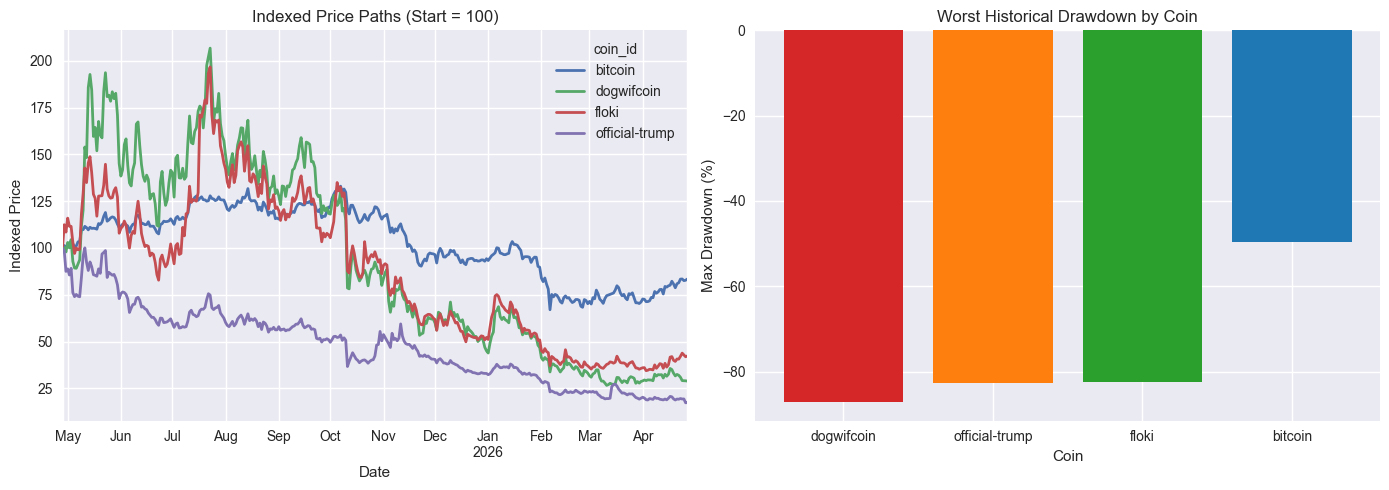

,coin_id,max_drawdown_pct
0,dogwifcoin,-87.14
1,official-trump,-82.73
2,floki,-82.49
3,bitcoin,-49.63


In [10]:
df_daily = (
    df.groupby(['date', 'coin_id'], as_index=False)
    .agg(
        price=('price', 'mean'),
        volume=('volume', 'mean'),
        daily_return_pct=('daily_return_pct', 'mean'),
    )
    .sort_values(['date', 'coin_id'])
)

price_wide = df_daily.pivot(index='date', columns='coin_id', values='price').sort_index()

indexed_price = price_wide.div(price_wide.iloc[0]).mul(100)
running_peak = indexed_price.cummax()
drawdown_pct = (indexed_price / running_peak - 1) * 100

max_drawdown = drawdown_pct.min().sort_values().reset_index()
max_drawdown.columns = ['coin_id', 'max_drawdown_pct']
max_drawdown['max_drawdown_pct'] = max_drawdown['max_drawdown_pct'].round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

indexed_price.plot(ax=axes[0], linewidth=2)
axes[0].set_title('Indexed Price Paths (Start = 100)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Indexed Price')

axes[1].bar(max_drawdown['coin_id'], max_drawdown['max_drawdown_pct'], color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[1].set_title('Worst Historical Drawdown by Coin')
axes[1].set_xlabel('Coin')
axes[1].set_ylabel('Max Drawdown (%)')

plt.tight_layout()
plt.show()

max_drawdown

### Risk vs Return
Meme coins have high risk but do not consistently provide higher returns.  
Bitcoin offers a more balanced and stable risk-return profile.

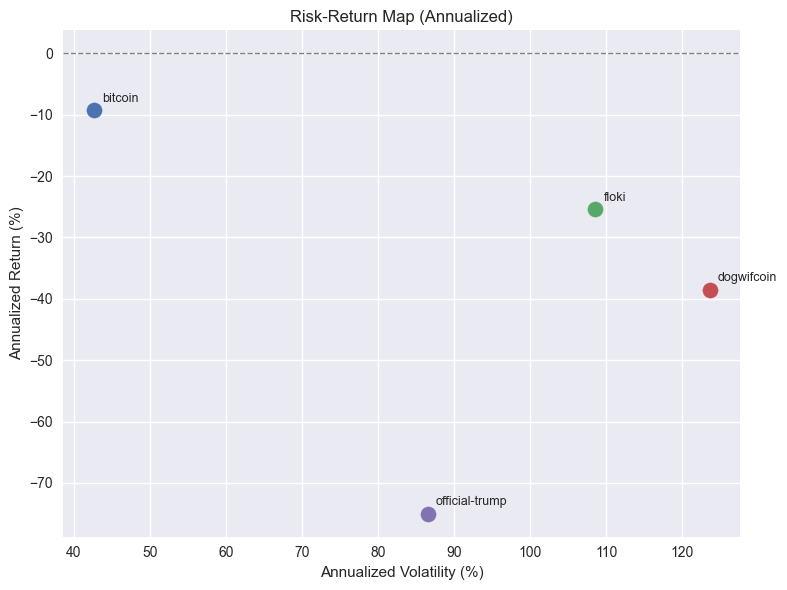

,coin_id,annual_return_pct,annual_volatility_pct,return_per_unit_risk
0,bitcoin,-9.28,42.65,-0.22
1,floki,-25.37,108.54,-0.23
2,dogwifcoin,-38.52,123.59,-0.31
3,official-trump,-75.02,86.55,-0.87


In [11]:
returns_wide = df_daily.pivot(index='date', columns='coin_id', values='daily_return_pct').sort_index()

returns_dec = returns_wide / 100

mean_daily = returns_dec.mean()
std_daily = returns_dec.std()

annual_return_pct = ((1 + mean_daily).clip(lower=1e-6) ** 365 - 1) * 100
annual_vol_pct = std_daily * (365 ** 0.5) * 100

sharpe_like = annual_return_pct / annual_vol_pct

risk_return = pd.DataFrame({
    'annual_return_pct': annual_return_pct,
    'annual_volatility_pct': annual_vol_pct,
    'return_per_unit_risk': sharpe_like,
}).round(2).sort_values('return_per_unit_risk', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in risk_return.iterrows():
    ax.scatter(row['annual_volatility_pct'], row['annual_return_pct'], s=120)
    ax.annotate(row['coin_id'], (row['annual_volatility_pct'], row['annual_return_pct']),
                textcoords='offset points', xytext=(6, 6), fontsize=9)

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Risk-Return Map (Annualized)')
ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')

plt.tight_layout()
plt.show()

risk_return

### Correlation
Meme coins move similarly, reducing diversification benefits.  
Bitcoin is less correlated and provides better portfolio balance.

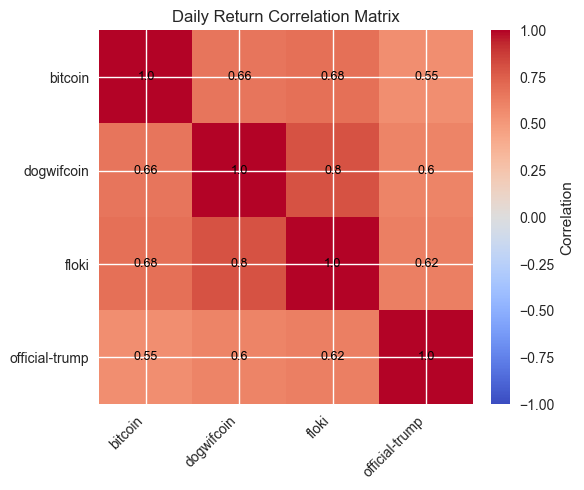

coin_id,bitcoin,dogwifcoin,floki,official-trump
coin_id,,,,
bitcoin,1.00,0.66,0.68,0.55
dogwifcoin,0.66,1.00,0.80,0.60
floki,0.68,0.80,1.00,0.62
official-trump,0.55,0.60,0.62,1.00


In [12]:
corr = returns_wide.corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, corr.iloc[i, j], ha='center', va='center', color='black', fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
ax.set_title('Daily Return Correlation Matrix')

plt.tight_layout()
plt.show()

corr

### Volume Spikes
Volume spikes sometimes lead to gains but often result in losses.  
This suggests hype-driven behavior and potential market inefficiencies.

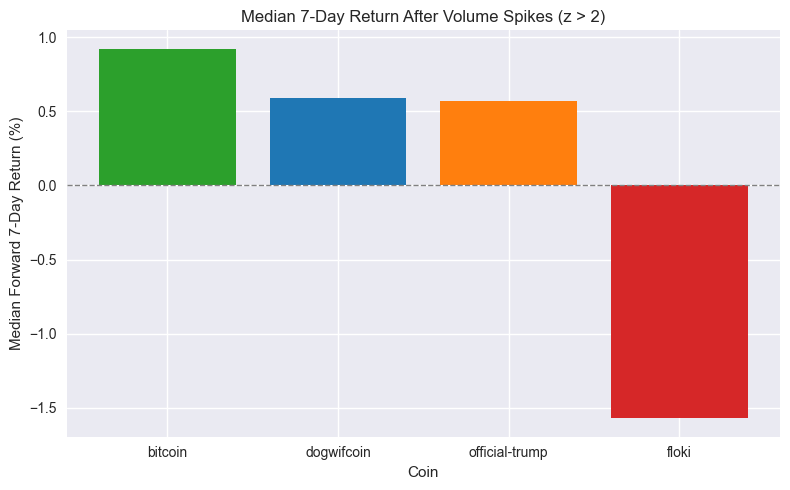

,coin_id,volume_spike_events,median_7d_return_after_spike_pct,mean_7d_return_after_spike_pct
0,bitcoin,14,0.92,1.16
1,dogwifcoin,14,0.59,0.62
3,official-trump,23,0.57,-2.48
2,floki,20,-1.57,-1.30


In [13]:
volume_wide = df_daily.pivot(index='date', columns='coin_id', values='volume').sort_index()
future_7d_return = (price_wide.shift(-7) / price_wide - 1) * 100

vol_mean_30 = volume_wide.rolling(30).mean()
vol_std_30 = volume_wide.rolling(30).std()
vol_zscore = (volume_wide - vol_mean_30) / vol_std_30

event_mask = vol_zscore > 2
event_summary = []

for coin in event_mask.columns:
    mask = event_mask[coin].fillna(False)
    coin_future = future_7d_return.loc[mask, coin].dropna()
    event_summary.append({
        'coin_id': coin,
        'volume_spike_events': int(mask.sum()),
        'median_7d_return_after_spike_pct': coin_future.median() if len(coin_future) else float('nan'),
        'mean_7d_return_after_spike_pct': coin_future.mean() if len(coin_future) else float('nan')
    })

event_summary_df = pd.DataFrame(event_summary).round(2).sort_values('median_7d_return_after_spike_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(event_summary_df['coin_id'], event_summary_df['median_7d_return_after_spike_pct'],
       color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'])

ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Median 7-Day Return After Volume Spikes (z > 2)')
ax.set_xlabel('Coin')
ax.set_ylabel('Median Forward 7-Day Return (%)')

plt.tight_layout()
plt.show()

event_summary_df

## Gold vs Crypto ($100 Benchmark)

This chart compares how $100 invested at the same starting date would have grown in gold versus selected cryptocurrencies.
Each asset is normalized to 100 at the start, so the lines show relative performance instead of raw prices and A higher ending line means stronger total performance since start.

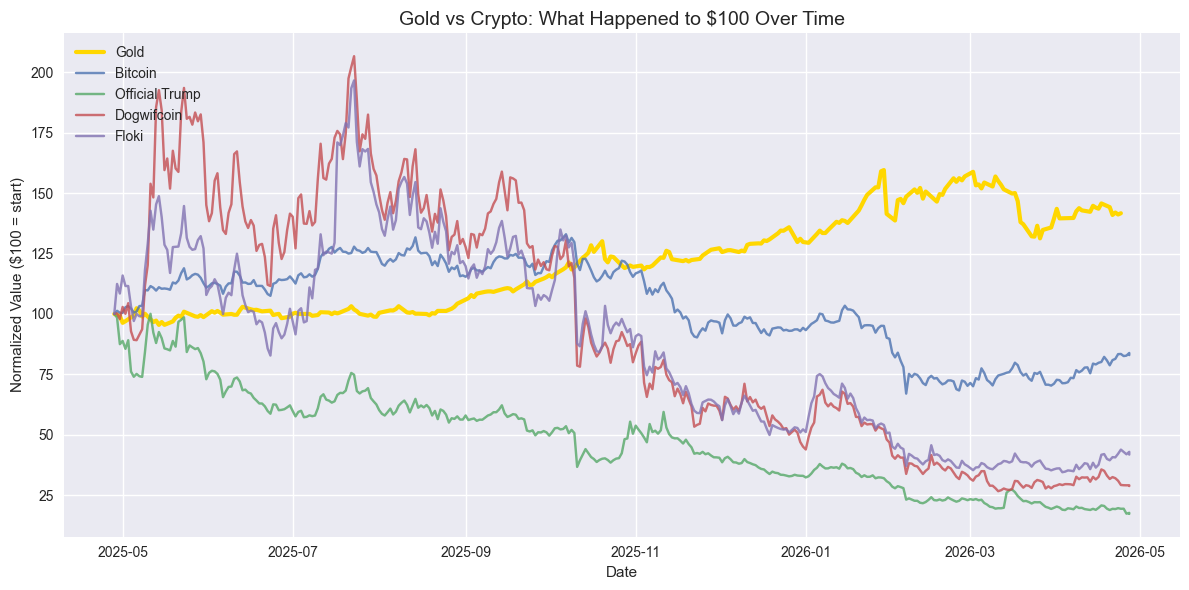

In [22]:
df = pd.read_csv('../data/interim/master_cleaned.csv', parse_dates=['date'])

start_date = df['date'].min().strftime('%Y-%m-%d')
end_date = df['date'].max().strftime('%Y-%m-%d')
gold_data = yf.download('GC=F', start=start_date, end=end_date, progress=False)
gold_close = gold_data['Close']

gold_start = gold_close.iloc[0]
gold_norm = (gold_close / gold_start) * 100

coins = ['bitcoin', 'official-trump', 'dogwifcoin', 'floki']

plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(gold_norm.index, gold_norm.values, label='Gold', linewidth=3, color='gold')

for coin in coins:
    coin_data = df[df['coin_id'] == coin].sort_values('date').copy()
    coin_start = coin_data['price'].iloc[0]
    coin_data['price_norm'] = (coin_data['price'] / coin_start) * 100
    ax.plot(coin_data['date'], coin_data['price_norm'], label=coin.replace('-', ' ').title(), alpha=0.8)

ax.set_title('Gold vs Crypto: What Happened to $100 Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value ($100 = start)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

